In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import faiss
import knowhere
import json
import time


def read_bin(file_path, dtype):
    data = np.fromfile(file_path).view('int32')
    n, d = data[:2]
    return data[2:].view(dtype).reshape(n, d)


def read_vecs(file_path, dtype):
    data = np.fromfile(file_path).view('int32')
    d = data[0]
    return data.reshape(-1, d+1)[:, 1:].view(dtype)


def read_data(file_path, dtype, format):
    if format == 'bin':
        return read_bin(file_path, dtype)
    elif format == 'vecs':
        return read_vecs(file_path, dtype)


datasetname = 'gist'
dir = '../dataset'
format = "vecs"
metric = "L2"
normalize = False
topk = 100

xb = read_data(f'{dir}/{datasetname}/{datasetname}_base.f{format}',
               'float32', format)
xq = read_data(
    f'{dir}/{datasetname}/{datasetname}_query.f{format}', 'float32', format)
gt = read_data(
    f'{dir}/{datasetname}/{datasetname}_groundtruth.i{format}', 'int32', format)[:, :topk]
if normalize:
    xb = xb / np.linalg.norm(xb, axis=1, keepdims=True)
    xq = xq / np.linalg.norm(xq, axis=1, keepdims=True)
n, d = xb.shape
nq = xq.shape[0]
print(f'n = {n}, d = {d}, nq = {nq}')


version = knowhere.GetCurrentVersion()

quant_types = ["SQ4", "RBQ1", "RBQ2", "RBQ3", "RBQ4"]
colors = ["red", "pink", "blue", "green", "yellow"]
markers = ['xovs*']
nbits = [4, 1, 2, 3, 4]
# dims = [128, 96, 64, 32]
# dims = [768, 640, 512, 384]
# dims = [960, 896, 832, 768, 704, 640, 576, 512, 448, 384, 320]
dims = [256, 512, 768, 960]
# dims = [100, 80, 64, 48]

efs = [50, 75, 100, 125, 150, 175, 200, 250, 300]
# efs = [100, 150, 200, 250, 300, 350, 400]

cfg = {
    "dim": d,
    "metric_type": metric,
    "M": 48,
    "efConstruction": 100,
    "k": topk,
    "ef": topk,
    "graph_build_algo": "vamana",
    "index_algo": "GRAPH",
    "refine_ratio": 1.5
}


def pca_transform(xb, xq, dim):
    d = xb.shape[1]
    pca = faiss.PCAMatrix(d, dim)
    pca.train(xb)
    xb = pca.apply_py(xb)
    xq = pca.apply_py(xq)
    return xb, xq


def rr_transform(xb, xq):
    d = xb.shape[1]
    rr = faiss.RandomRotationMatrix(d, d)
    rr.train(xb)
    xb = rr.apply_py(xb)
    xq = rr.apply_py(xq)
    return xb, xq


def pca_rr_transform(xb, xq, dim):
    xb, xq = pca_transform(xb, xq, dim)
    xb, xq = rr_transform(xb, xq)
    return xb, xq


mp = {}

for dim in dims:
    xb_use, xq_use = pca_rr_transform(xb, xq, dim)
    cfg["dim"] = dim
    cfg["build_quant_type"] = "SQ4"
    idx = knowhere.CreateIndex("HNSW", version)
    idx.Build(knowhere.ArrayToDataSet(xb_use), json.dumps(cfg))
    binset = knowhere.GetBinarySet()
    idx.Serialize(binset)
    index_file = f"test_{datasetname}_{dim}.index"
    knowhere.Dump(binset, index_file)
    for nbit, quant, color in zip(nbits, quant_types, colors):
        name = f"PCA{dim},{quant}"

        cfg["search_quant_type"] = quant
        new_binset = knowhere.GetBinarySet()
        knowhere.Load(new_binset, index_file)
        idx = knowhere.CreateIndex("HNSW", version)
        idx.Deserialize(new_binset, json.dumps(cfg))

        qpss = []
        recalls = []
        for ef in efs:
            cfg["ef"] = ef
            max_qps = 0
            for _ in range(10):
                t0 = time.time()
                ans, _ = idx.Search(knowhere.ArrayToDataSet(xq_use), json.dumps(cfg),
                                    knowhere.GetNullBitSetView())
                t1 = time.time()
                qps = nq / (t1 - t0)
                max_qps = max(max_qps, qps)

            k_dis, k_ids = knowhere.DataSetToArray(ans)

            cnt = 0
            for i in range(nq):
                cnt += np.intersect1d(k_ids[i], gt[i]).size
            recall = cnt / (nq * topk)
            print(f'{name} ef={ef} {recall} {max_qps}')
            if recall > 0.7:
                qpss.append(max_qps)
                recalls.append(recall)
        mp[name] = [qpss, recalls, color]

n = 1183514, d = 100, nq = 10000


I20250314 03:47:18.376025 185264 index_factory.cc:55] [KNOWHERE][Create][python] use key HNSW_fp32 to create knowhere index HNSW with version 6
I20250314 03:47:18.377161 185264 cardinal.cc:91] [KNOWHERE][Build][python] Index.Build with cardinal
I20250314 03:47:18.377234 185264 cardinal.cc:121] [KNOWHERE][Build][python] Plan to create Cardinal Index with BF16
I20250314 03:47:18.415504 185264 cardinal.cc:132] [KNOWHERE][Build][python] Load data with type BF16
W20250314 03:47:18.449172 185264 materialized_view.h:32] [CARDINAL][read_opt_scalar_ivf][python] path is empty
I20250314 03:47:18.542307 185264 graph_strategy.hpp:47] [CARDINAL][graph_build_dispatcher][python] Using SQ4 for graph building.
I20250314 03:47:18.542730 189197 thread_pool.h:68] [KNOWHERE][operator()][knowhere_build3] Successfully set priority of knowhere thread.
I20250314 03:47:18.542910 189198 thread_pool.h:68] [KNOWHERE][operator()][knowhere_build3] Successfully set priority of knowhere thread.
I20250314 03:47:18.54309

=============start optimization=============
PCA100,SQ4 ef=100 0.766579 122146.16872073247
PCA100,SQ4 ef=150 0.804054 96012.45278699782
PCA100,SQ4 ef=200 0.845894 76039.00659718382
PCA100,SQ4 ef=250 0.869171 60946.88966709775
PCA100,SQ4 ef=300 0.885317 49630.625343153035
PCA100,SQ4 ef=350 0.89746 45261.23139611175
PCA100,SQ4 ef=400 0.907136 40096.66860411759


I20250314 03:47:53.088938 185264 index_factory.cc:55] [KNOWHERE][Create][python] use key HNSW_fp32 to create knowhere index HNSW with version 6
I20250314 03:47:53.089886 185264 cardinal.cc:545] [KNOWHERE][Deserialize][python] Index.Deserialize with cardinal
I20250314 03:47:53.153556 185264 IVF.h:132] [CARDINAL][load][python] load BF16
I20250314 03:47:53.153612 185264 MaterializedViews.h:185] [CARDINAL][load][python] Loading MVs for 0 fields
I20250314 03:47:53.153622 185264 MaterializedViews.h:191] [CARDINAL][load][python] Loading MV only: 0
I20250314 03:47:53.153626 185264 HyperGraphVecIndex.cpp:375] [CARDINAL][load][python] Load quantizer SQ4 for graph search.
I20250314 03:47:53.161830 185264 cardinal.cc:599] [KNOWHERE][Deserialize][python] Cardinal success load with size = 582290641
I20250314 03:47:53.161916 185264 HyperGraphVecIndex.cpp:182] [CARDINAL][prepare][python] Replace searcher from_type = SQ4 to_type = RBQ1 for graph search during prepare stage.
I20250314 03:47:53.161929 18

=============start optimization=============
PCA100,RBQ1 ef=100 0.546663 92471.09660919794
PCA100,RBQ1 ef=150 0.553133 73607.52518339125
PCA100,RBQ1 ef=200 0.618742 58524.08327286934
PCA100,RBQ1 ef=250 0.666291 48161.45433835046
PCA100,RBQ1 ef=300 0.702391 41313.13857612975
PCA100,RBQ1 ef=350 0.730783 35993.80409084473
PCA100,RBQ1 ef=400 0.753973 31659.66440470709


...

=============start optimization=============
PCA48,RBQ2 ef=100 0.262024 100721.95646744664
PCA48,RBQ2 ef=150 0.26157 78642.06952025065
PCA48,RBQ2 ef=200 0.264945 62538.453739212375
PCA48,RBQ2 ef=250 0.266236 51203.75027467832
PCA48,RBQ2 ef=300 0.266764 43837.38491430172
PCA48,RBQ2 ef=350 0.267107 38375.71068604649
PCA48,RBQ2 ef=400 0.267396 33916.71680219432


I20250314 03:53:55.823850 185264 index_factory.cc:55] [KNOWHERE][Create][python] use key HNSW_fp32 to create knowhere index HNSW with version 6
I20250314 03:53:55.824839 185264 cardinal.cc:545] [KNOWHERE][Deserialize][python] Index.Deserialize with cardinal
I20250314 03:53:55.875165 185264 IVF.h:132] [CARDINAL][load][python] load BF16
I20250314 03:53:55.875221 185264 MaterializedViews.h:185] [CARDINAL][load][python] Loading MVs for 0 fields
I20250314 03:53:55.875231 185264 MaterializedViews.h:191] [CARDINAL][load][python] Loading MV only: 0
I20250314 03:53:55.875234 185264 HyperGraphVecIndex.cpp:375] [CARDINAL][load][python] Load quantizer RBQ4 for graph search.
I20250314 03:53:55.922371 185264 cardinal.cc:599] [KNOWHERE][Deserialize][python] Cardinal success load with size = 553887741
I20250314 03:53:55.922480 185264 HyperGraphVecIndex.cpp:182] [CARDINAL][prepare][python] Replace searcher from_type = RBQ4 to_type = RBQ3 for graph search during prepare stage.
I20250314 03:53:55.922493 

=============start optimization=============
PCA48,RBQ3 ef=100 0.267681 83241.45814810111
PCA48,RBQ3 ef=150 0.267747 64103.58535291861
PCA48,RBQ3 ef=200 0.268228 50247.373105826904
PCA48,RBQ3 ef=250 0.268241 41277.56312726228
PCA48,RBQ3 ef=300 0.268145 35293.11186280944
PCA48,RBQ3 ef=350 0.268025 30925.698174085643
PCA48,RBQ3 ef=400 0.267964 27237.79193757452
=============start optimization=============


I20250314 03:54:15.033066 185264 index_factory.cc:55] [KNOWHERE][Create][python] use key HNSW_fp32 to create knowhere index HNSW with version 6
I20250314 03:54:15.033950 185264 cardinal.cc:545] [KNOWHERE][Deserialize][python] Index.Deserialize with cardinal
I20250314 03:54:15.083591 185264 IVF.h:132] [CARDINAL][load][python] load BF16
I20250314 03:54:15.083648 185264 MaterializedViews.h:185] [CARDINAL][load][python] Loading MVs for 0 fields
I20250314 03:54:15.083658 185264 MaterializedViews.h:191] [CARDINAL][load][python] Loading MV only: 0
I20250314 03:54:15.083662 185264 HyperGraphVecIndex.cpp:375] [CARDINAL][load][python] Load quantizer RBQ4 for graph search.
I20250314 03:54:15.115283 185264 cardinal.cc:599] [KNOWHERE][Deserialize][python] Cardinal success load with size = 553887741
I20250314 03:54:15.115379 185264 mem_graph_searcher.cpp:57] [CARDINAL][preheat][python] Start preheating
I20250314 03:54:15.125202 185264 mem_graph_searcher.cpp:131] [CARDINAL][operator()][python] HNSW p

PCA48,RBQ4 ef=100 0.268348 80533.62620820485
PCA48,RBQ4 ef=150 0.268357 59781.472792421955
PCA48,RBQ4 ef=200 0.268445 46793.30661005169
PCA48,RBQ4 ef=250 0.268281 38427.81701109323
PCA48,RBQ4 ef=300 0.268169 32837.21469159212
PCA48,RBQ4 ef=350 0.268071 28749.691549272604
PCA48,RBQ4 ef=400 0.268016 25464.14666382538


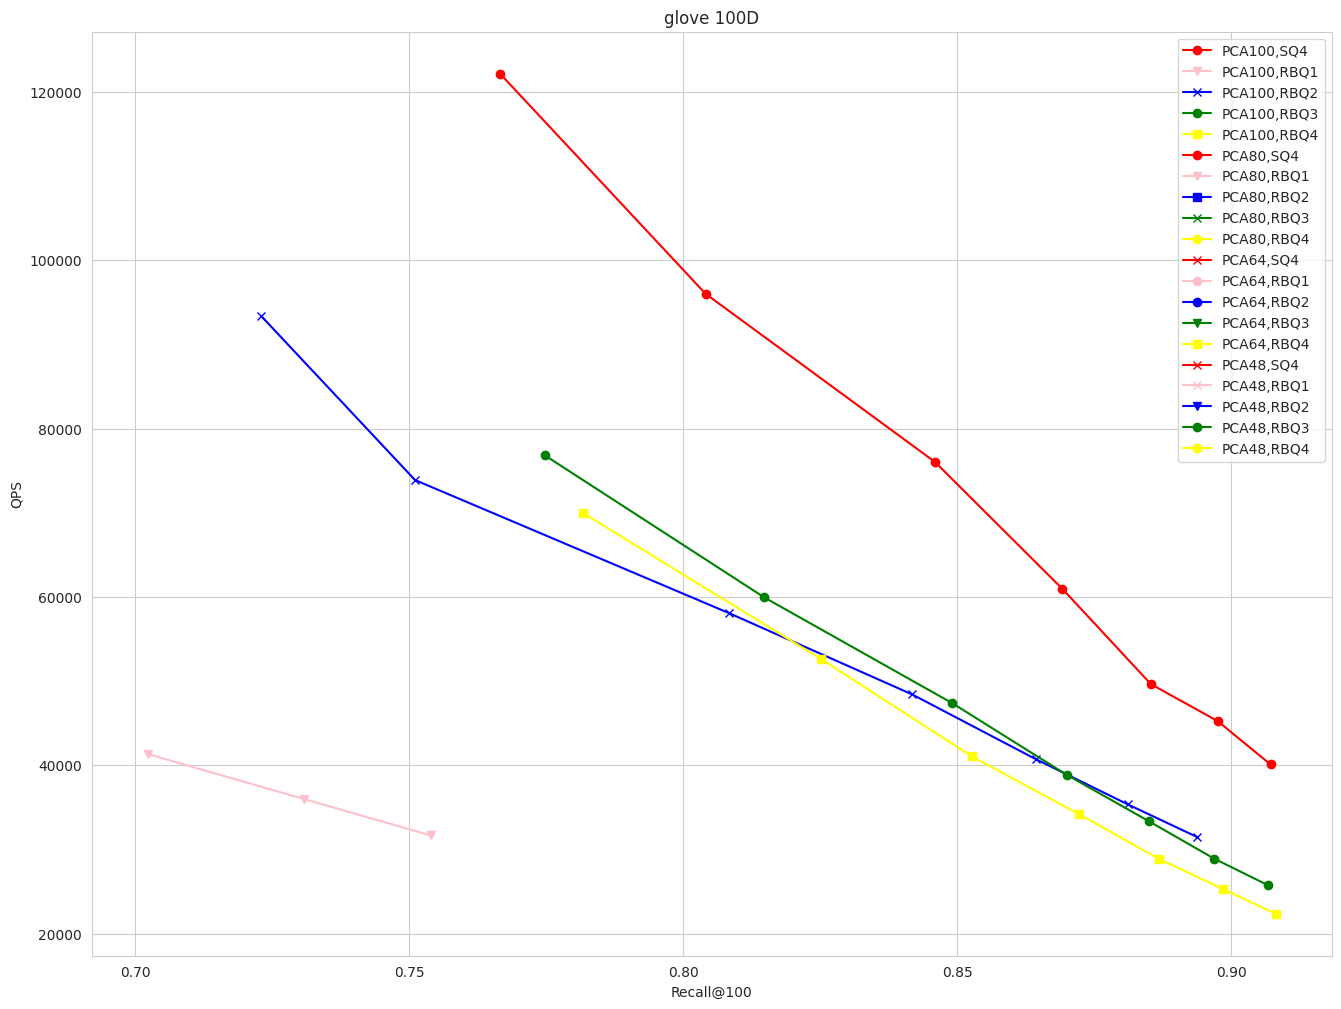

In [10]:
import random
sns.set_style('whitegrid')
plt.figure(figsize=(16, 12))
for name, (qpss, recalls, color) in mp.items():
    plt.plot(recalls, qpss, label=name, marker='xovs'[random.randint(0, 3)], c=color)
plt.legend()
plt.title(f'{datasetname} {d}D')
plt.xlabel('Recall@100')
plt.ylabel('QPS')
plt.savefig(f'pca_bench_qps_{datasetname}.png')



In [11]:

with open(f'fuck_{datasetname}.json', 'w') as f:
    json.dump(mp, f)

